# 7,4 Hamming Code

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def decision(r):
    if (r<0):
        return 1
    else:
        return 0

In [11]:
msg_int = np.arange(0, 16)
string_format = '{0:0'+str(4)+'b}'
msg_string = np.array([string_format.format(i) for i in msg_int])
msg_list = np.array([np.array(list(map(int, s))) for s in msg_string])

In [12]:
msg_list

array([[0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 1, 0, 0],
       [0, 1, 0, 1],
       [0, 1, 1, 0],
       [0, 1, 1, 1],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 0, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 0],
       [1, 1, 1, 1]])

In [13]:
G = np.array([[1, 0, 0, 0, 1, 0, 1],
              [0, 1, 0, 0, 1, 1, 1],
              [0, 0, 1, 0, 1, 1, 0],
              [0, 0, 0, 1, 0, 1, 1]])

In [15]:
cword_list = np.dot(msg_list, G) % 2
cword_list


array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 1],
       [0, 0, 1, 0, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 1],
       [0, 1, 0, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0],
       [0, 1, 1, 0, 0, 0, 1],
       [0, 1, 1, 1, 0, 1, 0],
       [1, 0, 0, 0, 1, 0, 1],
       [1, 0, 0, 1, 1, 1, 0],
       [1, 0, 1, 0, 0, 1, 1],
       [1, 0, 1, 1, 0, 0, 0],
       [1, 1, 0, 0, 0, 1, 0],
       [1, 1, 0, 1, 0, 0, 1],
       [1, 1, 1, 0, 1, 0, 0],
       [1, 1, 1, 1, 1, 1, 1]])

In [16]:
cword_list.shape

(16, 7)

## BER

In [18]:
# N = 1000

EbNodB_range = np.arange(0, 10, 1)
ber_hard = [None]*len(EbNodB_range)
ber_soft = [None]*len(EbNodB_range)
for db in range(0,len(EbNodB_range)):
    EbNodB = EbNodB_range[db]
    k = 4
    n = 7
    R = k/n
    EbNo = 10**(EbNodB /10)
    sigma = np.sqrt(1/(2*R*EbNo))

    N_errors_1 = 0
    N_errors_2 = 0
    N_blocks = 5
    for j in range(N_blocks):
        msg = np.random.randint(2,size=k)
        cword = np.array([msg[0], msg[1], msg[2], msg[3],
                          (msg[0] + msg[1] + msg[2])%2,
                          (msg[1] + msg[2] + msg[3])%2,
                          (msg[0] + msg[1] + msg[3])%2])
        print(cword)
        print(type(cword))
        s = 1 - 2*cword
        r = s + np.random.normal(0, sigma, n)

        b = np.array([decision(x) for x in r])

        #Hard decision
        b_list = np.tile(b,(16,1))
        dist = np.dot (((b_list + cword_list) % 2 ), np.ones(7).T)
        min_dist, pos = np.min(dist) , dist.tolist().index(np.min(dist))
        msg_cap_1 = msg_list[pos]


        #Soft decision
        corr = np.dot((1 - 2*cword_list), r)
        min_dist_2, pos_2 = np.max(corr) , corr.tolist().index(np.max(corr))
        msg_cap_2 = msg_list[pos_2]


        no_errors = (msg != msg_cap_1)
        no_errors=  no_errors.astype(int).sum()

        N_errors_1 = N_errors_1 + no_errors

        no_errors = (msg != msg_cap_2)
        no_errors=  no_errors.astype(int).sum()

        N_errors_2 = N_errors_2 + no_errors

    print(N_errors_1)
    print(N_errors_2)
    ber_hard[db] = N_errors_1 /(k*N_blocks)
    ber_soft[db] = N_errors_2 /(k*N_blocks)
    print ('EbNo(dB):',EbNodB_range[db],'\tBER:',ber_hard[db])
    print ('EbNo(dB):',EbNodB_range[db],'\tBER:',ber_soft[db])

[0 1 0 1 1 0 0]
<class 'numpy.ndarray'>
[1 1 0 1 0 0 1]
<class 'numpy.ndarray'>
[0 1 1 1 0 1 0]
<class 'numpy.ndarray'>
[1 0 0 0 1 0 1]
<class 'numpy.ndarray'>
[1 0 0 0 1 0 1]
<class 'numpy.ndarray'>
0
2
EbNo(dB): 0 	BER: 0.0
EbNo(dB): 0 	BER: 0.1
[0 1 0 0 1 1 1]
<class 'numpy.ndarray'>
[0 1 1 0 0 0 1]
<class 'numpy.ndarray'>
[1 0 1 1 0 0 0]
<class 'numpy.ndarray'>
[1 0 1 1 0 0 0]
<class 'numpy.ndarray'>
[0 0 1 1 1 0 1]
<class 'numpy.ndarray'>
0
0
EbNo(dB): 1 	BER: 0.0
EbNo(dB): 1 	BER: 0.0
[0 0 0 1 0 1 1]
<class 'numpy.ndarray'>
[0 0 0 1 0 1 1]
<class 'numpy.ndarray'>
[0 0 0 1 0 1 1]
<class 'numpy.ndarray'>
[0 1 1 1 0 1 0]
<class 'numpy.ndarray'>
[1 1 0 1 0 0 1]
<class 'numpy.ndarray'>
3
0
EbNo(dB): 2 	BER: 0.15
EbNo(dB): 2 	BER: 0.0
[1 0 1 1 0 0 0]
<class 'numpy.ndarray'>
[0 0 0 0 0 0 0]
<class 'numpy.ndarray'>
[0 0 1 1 1 0 1]
<class 'numpy.ndarray'>
[0 0 0 1 0 1 1]
<class 'numpy.ndarray'>
[1 0 0 0 1 0 1]
<class 'numpy.ndarray'>
0
0
EbNo(dB): 3 	BER: 0.0
EbNo(dB): 3 	BER: 0.0
[0 1 0 

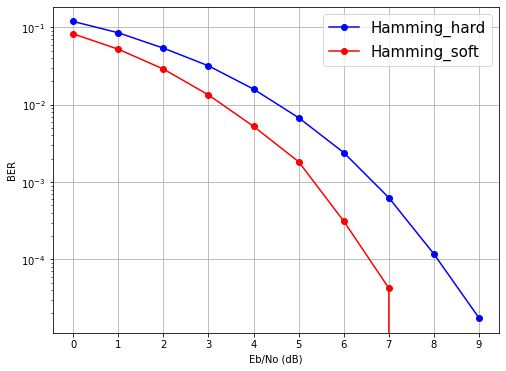

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(EbNodB_range, ber_hard, 'bo-', label = 'Hamming_hard')
plt.plot(EbNodB_range, ber_soft, 'ro-', label = 'Hamming_soft')
plt.yscale('log')
plt.xlabel('Eb/No (dB)')
plt.ylabel('BER')
plt.grid()
plt.legend(loc='upper right',ncol = 1, prop={'size': 15})
plt.xticks(np.arange(min(EbNodB_range), max(EbNodB_range)+1, 1))
# plt.ylim(1e-6)
plt.show()

## BLER

In [ ]:
# N = 1000

EbNodB_range = np.arange(0, 10, 1)
ber_hard = [None]*len(EbNodB_range)
ber_soft = [None]*len(EbNodB_range)
for db in range(0,len(EbNodB_range)):
    EbNodB = EbNodB_range[db]
    k = 4
    n = 7
    R = k/n
    EbNo = 10**(EbNodB /10)
    sigma = np.sqrt(1/(2*R*EbNo))

    N_errors_1 = 0
    N_errors_2 = 0
    N_blocks = 1000000
    for j in range(N_blocks):
        msg = np.random.randint(2,size=k)
        cword = np.array([msg[0], msg[1], msg[2], msg[3],
                          (msg[0] + msg[1] + msg[2])%2,
                          (msg[1] + msg[2] + msg[3])%2,
                          (msg[0] + msg[1] + msg[3])%2])
        s = 1 - 2*cword
        r = s + np.random.normal(0, sigma, n)

        b = np.array([decision(x) for x in r])


        #Hard decision
        b_list = np.tile(b,(16,1))
        dist = np.dot (((b_list + cword_list) % 2 ), np.ones(7).T)
        min_dist, pos = np.min(dist) , dist.tolist().index(np.min(dist))
        msg_cap_1 = msg_list[pos]


        #Soft decision
        corr = np.dot((1 - 2*cword_list), r)
        min_dist_2, pos_2 = np.max(corr) , corr.tolist().index(np.max(corr))
        msg_cap_2 = msg_list[pos_2]


        no_errors = (msg != msg_cap_1)
        no_errors=  no_errors.astype(int).sum()

        if (no_errors != 0):
            N_errors_1 = N_errors_1 + 1

        no_errors = (msg != msg_cap_2)
        no_errors=  no_errors.astype(int).sum()

        if (no_errors != 0):
            N_errors_2 = N_errors_2 + 1

    print(N_errors_1)
    print(N_errors_2)
    ber_hard[db] = N_errors_1 /N_blocks
    ber_soft[db] = N_errors_2 /N_blocks
    print ('EbNo(dB):',EbNodB_range[db],'\tBLER:',ber_hard[db])
    print ('EbNo(dB):',EbNodB_range[db],'\tBLER:',ber_soft[db])

263021
179834
EbNo(dB): 0 	BLER: 0.263021
EbNo(dB): 0 	BLER: 0.179834
189178
114945
EbNo(dB): 1 	BLER: 0.189178
EbNo(dB): 1 	BLER: 0.114945
123686
64099
EbNo(dB): 2 	BLER: 0.123686
EbNo(dB): 2 	BLER: 0.064099
72247
30698
EbNo(dB): 3 	BLER: 0.072247
EbNo(dB): 3 	BLER: 0.030698
36802
11825
EbNo(dB): 4 	BLER: 0.036802
EbNo(dB): 4 	BLER: 0.011825
15617
3611
EbNo(dB): 5 	BLER: 0.015617
EbNo(dB): 5 	BLER: 0.003611
5361
788
EbNo(dB): 6 	BLER: 0.005361
EbNo(dB): 6 	BLER: 0.000788
1404
119
EbNo(dB): 7 	BLER: 0.001404
EbNo(dB): 7 	BLER: 0.000119
285
12
EbNo(dB): 8 	BLER: 0.000285
EbNo(dB): 8 	BLER: 1.2e-05
41
2
EbNo(dB): 9 	BLER: 4.1e-05
EbNo(dB): 9 	BLER: 2e-06


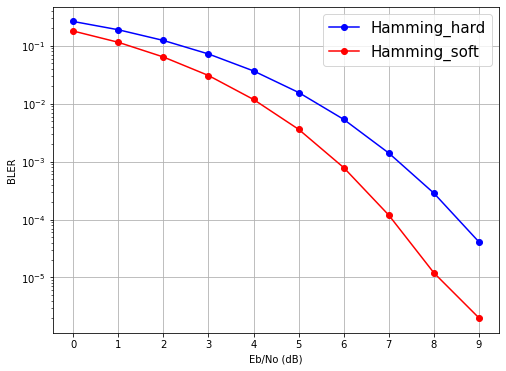

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(EbNodB_range, ber_hard, 'bo-', label = 'Hamming_hard')
plt.plot(EbNodB_range, ber_soft, 'ro-', label = 'Hamming_soft')
plt.yscale('log')
plt.xlabel('Eb/No (dB)')
plt.ylabel('BLER')
plt.grid()
plt.legend(loc='upper right',ncol = 1, prop={'size': 15})
plt.xticks(np.arange(min(EbNodB_range), max(EbNodB_range)+1, 1))
# plt.ylim(1e-6)
plt.show()

# 15, 11, Hamming Code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def decision(r):
    if (r<0):
        return 1
    else:
        return 0

In [ ]:
msg_int = np.arange(0, 221)
string_format = '{0:0'+str(11)+'b}'
msg_string = np.array([string_format.format(i) for i in msg_int])
msg_list = np.array([np.array(list(map(int, s))) for s in msg_string])

In [ ]:
G = np.array([[ 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
              [ 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
              [ 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
              [ 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0],
              [ 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
              [ 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1],
              [ 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1],
              [ 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1],
              [ 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
              [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1],
              [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1] ] )

In [ ]:
cword_list = np.dot(msg_list, G) % 2

In [ ]:
cword_list.shape

(221, 15)

## BER

In [ ]:
# N = 1000

EbNodB_range = np.arange(0, 10, 1)
ber_hard = [None]*len(EbNodB_range)
ber_soft = [None]*len(EbNodB_range)
for db in range(0,len(EbNodB_range)):
    EbNodB = EbNodB_range[db]
    k = 11
    n = 15
    R = k/n
    EbNo = 10**(EbNodB /10)
    sigma = np.sqrt(1/(2*R*EbNo))

    N_errors_1 = 0
    N_errors_2 = 0
    N_blocks = 100000
    for j in range(N_blocks):
        msg = np.random.randint(2,size=k)
        cword = np.array([msg[0], msg[1], msg[2], msg[3],msg[4], msg[5], msg[6], msg[7],
                          msg[8], msg[9], msg[10],
                          (msg[0] + msg[1] + msg[3]+ msg[4]+ msg[6]+ msg[8]+ msg[10])%2,
                          (msg[0] + msg[2] + msg[3]+ msg[5]+ msg[6]+ msg[9]+ msg[10])%2,
                          (msg[0] + msg[1] + msg[3]+ msg[7]+ msg[8]+ msg[9]+ msg[10])%2,
                          (msg[4] + msg[5] + msg[6]+ msg[7]+ msg[8]+ msg[9]+ msg[10])%2])
        s = 1 - 2*cword
        r = s + np.random.normal(0, sigma, n)

        b = np.array([decision(x) for x in r])

        #Hard decision
        b_list = np.tile(b,(221,1))
        dist = np.dot (((b_list + cword_list) % 2 ), np.ones(15).T)
        min_dist, pos = np.min(dist) , dist.tolist().index(np.min(dist))
        msg_cap_1 = msg_list[pos]


        #Soft decision
        corr = np.dot((1 - 2*cword_list), r)
        min_dist_2, pos_2 = np.max(corr) , corr.tolist().index(np.max(corr))
        msg_cap_2 = msg_list[pos_2]


        no_errors = (msg != msg_cap_1)
        no_errors=  no_errors.astype(int).sum()

        N_errors_1 = N_errors_1 + no_errors

        no_errors = (msg != msg_cap_2)
        no_errors=  no_errors.astype(int).sum()

        N_errors_2 = N_errors_2 + no_errors

    print(N_errors_1)
    print(N_errors_2)
    ber_hard[db] = N_errors_1 /(k*N_blocks)
    ber_soft[db] = N_errors_2 /(k*N_blocks)
    print ('EbNo(dB):',EbNodB_range[db],'\tBER:',ber_hard[db])
    print ('EbNo(dB):',EbNodB_range[db],'\tBER:',ber_soft[db])

302767
289178
EbNo(dB): 0 	BER: 0.27524272727272725
EbNo(dB): 0 	BER: 0.2628890909090909


KeyboardInterrupt: ignored